# Monte Carlo: устойчивость калибровок PD к составу портфеля

Проверяем, насколько результаты сравнения калибраторов зависят от конкретного сгенерированного портфеля. Логика:

- **бустинг и все калибраторы обучаются один раз** на полном in-time периоде 2020-2023 — внутри сценариев ничего не переобучается;
- каждый сценарий независимо берет **~80% наблюдений без возврата** отдельно из in-time и отдельно из OOT 2024;
- подвыборки прогоняются через уже готовый пайплайн `score -> calibrated PD -> EL / UL / Capital / RWA`;
- по каждому сценарию и методу считаются:
  - p-value биномиального теста на IN-TIME и на OOT — **тест модели целиком (само-калибровка)**: суммарный факт дефолтов против суммы предсказанных моделью PD. Корректно построенная, приведённая к ЦТ модель его проходит. По-грейдовая разбивка по фиксированной мастер-шкале A1…E вынесена в диагностику (раздел 3c), потому что она тестирует соответствие фиксированной шкале ментора, а не корректность самой модели;
  - средний PD на OOT;
  - Expected Loss, Unexpected Loss capital, их сумму **EL + UL** (полный экономический капитал) и RWA (те же допущения, что в разделе 8.1: EAD = 1 млн на актив, LGD = 40%, M = 2.5). Отдельная колонка Required Capital убрана: она тождественно равна UL (`required_capital = capital_ratio · RWA = UL`), поэтому вместо неё показываем EL + UL.

Итоговая таблица показывает для каждого метода **среднее, минимум, максимум и разницу max-min** — чем уже разброс, тем меньше результат зависит от случайного состава портфеля.

Вычислительный движок лежит в `notebooks/monte_carlo.py`; этот ноутбук — его отчетная обертка с таблицами и графиками.

In [1]:
import sys

for extra_path in ("..", "."):
    if extra_path not in sys.path:
        sys.path.append(extra_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.ticker import PercentFormatter

from src.monte_carlo import (
    METRIC_COLUMNS,
    prepare_fixed_pipeline,
    run_scenario,
    summarize_monte_carlo,
    cross_method_spread,
    summarize_cross_method_spread,
    whole_model_binomial_p_value,
    independent_portfolio_check,
    summarize_independent_portfolio_check,
    DEFAULT_CHECK_SEEDS,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
COLORS = ["#e74c3c", "#2980b9", "#27ae60", "#e67e22", "#8e44ad", "#16a085"]

N_SCENARIOS = 1000
SAMPLE_FRAC = 0.8

print(f"Сценариев: {N_SCENARIOS} | доля подвыборки: {SAMPLE_FRAC:.0%}")

Сценариев: 1000 | доля подвыборки: 80%


## 1. Фиксированный пайплайн

Один раз генерируем тот же синтетический stress-портфель (random_state=42, как в основном ноутбуке), обучаем бустинг и все пять калибраторов на полном in-time. Дальше эти объекты не меняются.

In [2]:
pipeline = prepare_fixed_pipeline(portfolio="stress", random_state=42)

n_intime = len(pipeline["y_calib"])
n_oot = len(pipeline["y_test"])
ct_intime = float(pipeline["y_calib"].mean())
dr_oot = float(pipeline["y_test"].mean())

print(f"In-time (2020-2023): {n_intime:,} строк | ЦТ = {ct_intime:.2%}")
print(f"OOT (2024):          {n_oot:,} строк | фактическая доля дефолтов = {dr_oot:.2%}")
print(f"Размер сценарной подвыборки: ~{int(n_intime * SAMPLE_FRAC):,} in-time / ~{int(n_oot * SAMPLE_FRAC):,} OOT строк")
print(f"Методы: {', '.join(pipeline['methods'])}")
print("\nПер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует")
print("свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.")

In-time (2020-2023): 31,224 строк | ЦТ = 3.59%
OOT (2024):          8,776 строк | фактическая доля дефолтов = 3.26%
Размер сценарной подвыборки: ~24,979 in-time / ~7,020 OOT строк
Методы: Логит-калибровка, Изотоническая регрессия, Бета-калибровка, Монотонный сплайн, Французский сплайн

Пер-строчные PD и IRB-капитал предвычислены один раз; сценарий только индексирует
свою случайную ~80%-подвыборку — поэтому 1000 сценариев считаются за минуты.


## 2. Прогон сценариев

Каждый сценарий использует свой seed (0..N-1), поэтому весь эксперимент воспроизводим. При 1000 сценариях таблица целиком (5000 строк) не нужна — ниже показаны первые 5 сценариев для наглядности формата, все данные лежат в `scenario_results`.

In [3]:
scenario_results = pd.concat(
    [run_scenario(pipeline, scenario_seed=seed, sample_frac=SAMPLE_FRAC) for seed in range(N_SCENARIOS)],
    ignore_index=True,
)

money_cols = ["expected_loss", "unexpected_loss_capital", "el_plus_ul", "rwa"]
scenario_view = scenario_results.copy()
for col in money_cols:
    scenario_view[col + "_bln"] = scenario_view[col] / 1e9
scenario_view = scenario_view.drop(columns=money_cols)

n_preview = 5 * scenario_results["method"].nunique()
print(f"Всего строк: {len(scenario_results)} ({N_SCENARIOS} сценариев x {scenario_results['method'].nunique()} методов)")
print(f"Ниже — первые 5 сценариев ({n_preview} строк):")
display(
    scenario_view.head(n_preview).style.format({
        "p_value_intime": "{:.6f}",
        "p_value_oot": "{:.6f}",
        "p_value_grade_intime": "{:.6f}",
        "p_value_grade_oot": "{:.6f}",
        "oot_mean_pd": "{:.4%}",
        "expected_loss_bln": "{:.4f}",
        "unexpected_loss_capital_bln": "{:.4f}",
        "el_plus_ul_bln": "{:.4f}",
        "rwa_bln": "{:.4f}",
    }).hide(axis="index")
)

Всего строк: 5000 (1000 сценариев x 5 методов)
Ниже — первые 5 сценариев (25 строк):


scenario,method,p_value_intime,p_value_oot,p_value_grade_intime,p_value_grade_oot,oot_mean_pd,expected_loss_bln,unexpected_loss_capital_bln,el_plus_ul_bln,rwa_bln
0,Логит-калибровка,0.759264,0.021329,0.000507,0.010442,3.6179%,0.1016,0.4725,0.5741,5.9060
0,Изотоническая регрессия,0.798290,0.023084,0.024109,0.006384,3.6116%,0.1014,0.4702,0.5716,5.8776
0,Бета-калибровка,0.772218,0.019674,0.002259,0.004524,3.6201%,0.1017,0.4658,0.5675,5.8229
0,Монотонный сплайн,0.759267,0.021324,0.002097,0.000100,3.6174%,0.1016,0.4772,0.5788,5.9647
0,Французский сплайн,0.759265,0.021330,0.141065,0.006046,3.6179%,0.1016,0.4760,0.5777,5.9506
1,Логит-калибровка,0.810733,0.286527,0.089206,0.069913,3.7664%,0.1058,0.4788,0.5846,5.9853
1,Изотоническая регрессия,0.837258,0.273003,0.011302,0.056917,3.7712%,0.1059,0.4763,0.5822,5.9536
1,Бета-калибровка,0.810718,0.286626,0.096165,0.042560,3.7697%,0.1059,0.4724,0.5782,5.9044
1,Монотонный сплайн,0.810710,0.273010,0.005232,0.000572,3.7731%,0.1060,0.4835,0.5895,6.0439
1,Французский сплайн,0.810710,0.273002,0.028147,0.018948,3.7718%,0.1059,0.4824,0.5883,6.0297


### Полная выгрузка всех сценариев

Все 1000 сценариев (5000 строк) сохраняются в `docs/monte_carlo_scenarios.csv`, чтобы с ними можно было ознакомиться отдельно — открыть в Excel или прямо на GitHub (там CSV показывается как таблица с поиском и сортировкой). Денежные метрики — в исходных единицах (рубли), `oot_mean_pd` и p-value — как доли.

In [4]:
from pathlib import Path

csv_path = Path("..") / "docs" / "monte_carlo_scenarios.csv"
export = scenario_results.sort_values(["scenario", "method"]).reset_index(drop=True)
export.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"Сохранено {len(export)} строк ({export['scenario'].nunique()} сценариев x {export['method'].nunique()} методов)")
print(f"Файл: docs/monte_carlo_scenarios.csv")
print(f"Колонки: {', '.join(export.columns)}")

Сохранено 5000 строк (1000 сценариев x 5 методов)
Файл: docs/monte_carlo_scenarios.csv
Колонки: scenario, method, p_value_intime, p_value_oot, p_value_grade_intime, p_value_grade_oot, oot_mean_pd, expected_loss, unexpected_loss_capital, el_plus_ul, rwa


## 3. Итоговая таблица: среднее / минимум / максимум / разброс

Ключевой показатель — **range (max - min)**: он показывает, насколько сильно метрика гуляет между сценариями при неизменной модели и калибровке.

In [5]:
summary = summarize_monte_carlo(scenario_results)

metric_titles = {
    "p_value_intime": ("Whole-model binomial p-value (само-калибровка), IN-TIME", "{:.6f}"),
    "p_value_oot": ("Whole-model binomial p-value (само-калибровка), OOT", "{:.6f}"),
    "p_value_grade_intime": ("По-грейдовый p-value vs мастер-шкала (Holm), IN-TIME", "{:.6f}"),
    "p_value_grade_oot": ("По-грейдовый p-value vs мастер-шкала (Holm), OOT", "{:.6f}"),
    "oot_mean_pd": ("Средний PD на OOT", "{:.4%}"),
    "expected_loss": ("Expected Loss, млрд", None),
    "unexpected_loss_capital": ("UL capital, млрд", None),
    "el_plus_ul": ("EL + UL (экономический капитал), млрд", None),
    "rwa": ("RWA, млрд", None),
}

for metric in METRIC_COLUMNS:
    title, fmt = metric_titles[metric]
    block = summary[["method"] + [f"{metric}_{s}" for s in ("mean", "min", "max", "range")]].copy()
    block.columns = ["method", "mean", "min", "max", "range (max-min)"]
    if fmt is None:
        for col in ("mean", "min", "max", "range (max-min)"):
            block[col] = block[col] / 1e9
        fmt = "{:.4f}"
    print(title)
    display(block.style.format({c: fmt for c in ("mean", "min", "max", "range (max-min)")}).hide(axis="index"))

Whole-model binomial p-value (само-калибровка), IN-TIME


method,mean,min,max,range (max-min)
Бета-калибровка,0.761320,0.195971,1.000000,0.804029
Изотоническая регрессия,0.762181,0.202023,1.000000,0.797977
Логит-калибровка,0.761479,0.196096,1.000000,0.803904
Монотонный сплайн,0.761382,0.195965,1.000000,0.804035
Французский сплайн,0.761454,0.195980,1.000000,0.804020


Whole-model binomial p-value (само-калибровка), OOT


method,mean,min,max,range (max-min)
Бета-калибровка,0.068839,0.001162,0.485795,0.484633
Изотоническая регрессия,0.072343,0.001286,0.505440,0.504154
Логит-калибровка,0.071807,0.001286,0.505484,0.504198
Монотонный сплайн,0.069019,0.001287,0.485785,0.484497
Французский сплайн,0.069492,0.001287,0.485758,0.484471


По-грейдовый p-value vs мастер-шкала (Holm), IN-TIME


...

method,mean,min,max,range (max-min)
Бета-калибровка,0.4700,0.4648,0.4752,0.0104
Изотоническая регрессия,0.4741,0.4694,0.4792,0.0097
Логит-калибровка,0.4765,0.4715,0.4816,0.0101
Монотонный сплайн,0.4812,0.4763,0.4860,0.0096
Французский сплайн,0.4800,0.4752,0.4849,0.0097


EL + UL (экономический капитал), млрд


method,mean,min,max,range (max-min)
Бета-калибровка,0.5739,0.5659,0.5824,0.0165
Изотоническая регрессия,0.5779,0.5703,0.5863,0.0161
Логит-калибровка,0.5803,0.5725,0.5886,0.0161
Монотонный сплайн,0.5851,0.5774,0.5931,0.0158
Французский сплайн,0.5840,0.5762,0.5921,0.0158


RWA, млрд


method,mean,min,max,range (max-min)
Бета-калибровка,5.8746,5.8104,5.9399,0.1295
Изотоническая регрессия,5.9266,5.8678,5.9895,0.1217
Логит-калибровка,5.9562,5.8935,6.0198,0.1263
Монотонный сплайн,6.0147,5.9543,6.0747,0.1204
Французский сплайн,6.0006,5.9399,6.0616,0.1216


## 3a. Межметодный разброс EL + UL внутри одного сценария

Сводка выше меряет разброс **одного метода по 1000 сценариев**. Здесь — ортогональный срез: внутри **одного** сценария (одна фиксированная ~80%-подвыборка, все 5 методов оценивают одних и тех же заёмщиков) насколько далеко методы расходятся по полному экономическому капиталу EL + UL?

Для каждого сценария берём самый дешёвый и самый дорогой по EL + UL метод, абсолютную разницу `max − min` и относительную `(max − min) / min` — то есть на сколько процентов самый консервативный метод требует больше капитала, чем самый экономный, при **одном и том же портфеле**. Таблица — одна строка на сценарий (транспонированная ориентация), все 1000 строк выгружаются в `docs/monte_carlo_cross_method_spread.csv`.

In [6]:
spread = cross_method_spread(scenario_results)
spread_stats, spread_counts = summarize_cross_method_spread(spread)

spread_csv_path = Path("..") / "docs" / "monte_carlo_cross_method_spread.csv"
spread.to_csv(spread_csv_path, index=False, encoding="utf-8-sig")

spread_view = spread.assign(
    min_el_plus_ul_bln=lambda d: d["min_el_plus_ul"] / 1e9,
    max_el_plus_ul_bln=lambda d: d["max_el_plus_ul"] / 1e9,
    abs_diff_bln=lambda d: d["abs_diff"] / 1e9,
)[["scenario", "min_method", "max_method", "min_el_plus_ul_bln", "max_el_plus_ul_bln", "abs_diff_bln", "rel_diff"]]

print(f"Первые 8 сценариев из {spread['scenario'].nunique()} (полная таблица — docs/monte_carlo_cross_method_spread.csv):")
display(
    spread_view.head(8).style.format({
        "min_el_plus_ul_bln": "{:.4f}",
        "max_el_plus_ul_bln": "{:.4f}",
        "abs_diff_bln": "{:.4f}",
        "rel_diff": "{:.4%}",
    }).hide(axis="index")
)

abs_summary = (spread_stats.loc[spread_stats["quantity"] == "abs_diff", ["mean", "median", "min", "max"]] / 1e9).copy()
abs_summary.insert(0, "показатель", "abs (max − min), млрд")
rel_summary = spread_stats.loc[spread_stats["quantity"] == "rel_diff", ["mean", "median", "min", "max"]].copy()
rel_summary.insert(0, "показатель", "rel (max − min) / min")

print("\nСводка межметодного разброса EL + UL по всем сценариям:")
display(abs_summary.style.format({c: "{:.4f}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))
display(rel_summary.style.format({c: "{:.4%}" for c in ("mean", "median", "min", "max")}).hide(axis="index"))

print("Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:")
display(spread_counts.style.format({"times_cheapest": "{:.0f}", "times_most_expensive": "{:.0f}"}).hide(axis="index"))

Первые 8 сценариев из 1000 (полная таблица — docs/monte_carlo_cross_method_spread.csv):


scenario,min_method,max_method,min_el_plus_ul_bln,max_el_plus_ul_bln,abs_diff_bln,rel_diff
0,Бета-калибровка,Монотонный сплайн,0.5675,0.5788,0.0113,1.9854%
1,Бета-калибровка,Монотонный сплайн,0.5782,0.5895,0.0113,1.9458%
2,Бета-калибровка,Монотонный сплайн,0.5762,0.5875,0.0112,1.9518%
3,Бета-калибровка,Монотонный сплайн,0.5747,0.5857,0.0110,1.9207%
4,Бета-калибровка,Монотонный сплайн,0.5774,0.5887,0.0113,1.9507%
5,Бета-калибровка,Монотонный сплайн,0.5714,0.5826,0.0113,1.9710%
6,Бета-калибровка,Монотонный сплайн,0.5729,0.5840,0.0111,1.9448%
7,Бета-калибровка,Монотонный сплайн,0.5723,0.5837,0.0114,1.9838%



Сводка межметодного разброса EL + UL по всем сценариям:


показатель,mean,median,min,max
"abs (max − min), млрд",0.0112,0.0112,0.0104,0.0123


показатель,mean,median,min,max
rel (max − min) / min,1.9519%,1.9522%,1.8044%,2.1579%


Как часто метод оказывался самым дешёвым / самым дорогим по EL + UL:


method,times_cheapest,times_most_expensive
Бета-калибровка,1000,0
Монотонный сплайн,0,1000


## 3b. Калибровочные тесты: устойчивость по сценариям

**Главный тест — whole-model** (само-калибровка): суммарный факт дефолтов против суммы предсказанных моделью PD, отдельно IN-TIME и OOT. Это тест модели в совокупности, а не отдельного грейда. Корректно построенная модель его проходит (p не мал).

**Вторичная диагностика — по-грейдовый тест** против фиксированной мастер-шкалы ментора. Он берёт худший грейд, поэтому обязан нести поправку на множественность: минимум по ~13 грейдам опускается ниже 0.05 примерно в 49% случаев даже у идеальной модели. Поправка (Холм) уже внутри `master_scale_grade_binomial_p_value`, поэтому колонки ниже сравниваются с обычными 0.05.

По-грейдовый тест строже whole-model **по построению**: грейд задаётся ПРЕДСКАЗАННЫМ PD, поэтому в один бакет попадают заёмщики разного истинного риска, и их фактическая дефолтность тянется к среднему портфеля, а не к representative PD бакета (regression to the mean). Это свойство бакетирования неидеального ранжирования, а не признак разладки калибровки — поэтому выводы делаются по whole-model.

С 1000 сценариев смотрим не отдельные p-value, а **долю сценариев, где модель проходит** (p ≥ 0.05).

In [7]:
alpha_level = 0.05
pass_share = (
    scenario_results
    .assign(
        pass_intime=lambda d: d["p_value_intime"] >= alpha_level,
        pass_oot=lambda d: d["p_value_oot"] >= alpha_level,
        pass_grade_intime=lambda d: d["p_value_grade_intime"] >= alpha_level,
        pass_grade_oot=lambda d: d["p_value_grade_oot"] >= alpha_level,
    )
    .groupby("method")
    .agg(
        share_pass_intime=("pass_intime", "mean"),
        share_pass_oot=("pass_oot", "mean"),
        median_p_oot=("p_value_oot", "median"),
        min_p_oot=("p_value_oot", "min"),
        share_pass_grade_intime=("pass_grade_intime", "mean"),
        share_pass_grade_oot=("pass_grade_oot", "mean"),
    )
    .reset_index()
    .sort_values("share_pass_oot")
)

display(
    pass_share.style.format({
        "share_pass_intime": "{:.1%}",
        "share_pass_oot": "{:.1%}",
        "median_p_oot": "{:.3f}",
        "min_p_oot": "{:.3f}",
        "share_pass_grade_intime": "{:.1%}",
        "share_pass_grade_oot": "{:.1%}",
    }).hide(axis="index")
)
print(f"share_pass_intime / share_pass_oot — доля из {N_SCENARIOS} сценариев, где модель ПРОХОДИТ главный whole-model тест (p >= {alpha_level:.0%}).")
print("min_p_oot — худший p-value по всем сценариям на главном тесте.")
print("share_pass_grade_* — то же для вторичного по-грейдового теста против фиксированной шкалы (уже с поправкой Холма).")
print("Он строже по построению (regression to the mean при бакетировании по предсказанному PD), поэтому его доля ниже — выводы делаются по whole-model.")


method,share_pass_intime,share_pass_oot,median_p_oot,min_p_oot,share_pass_grade_intime,share_pass_grade_oot
Монотонный сплайн,100.0%,49.8%,0.050,0.001,2.5%,0.0%
Бета-калибровка,100.0%,50.0%,0.050,0.001,66.5%,32.3%
Французский сплайн,100.0%,50.1%,0.050,0.001,79.5%,15.8%
Изотоническая регрессия,100.0%,52.5%,0.053,0.001,51.7%,30.1%
Логит-калибровка,100.0%,52.5%,0.052,0.001,46.2%,44.0%


share_pass_intime / share_pass_oot — доля из 1000 сценариев, где модель ПРОХОДИТ главный whole-model тест (p >= 5%).
min_p_oot — худший p-value по всем сценариям на главном тесте.
share_pass_grade_* — то же для вторичного по-грейдового теста против фиксированной шкалы (уже с поправкой Холма).
Он строже по построению (regression to the mean при бакетировании по предсказанному PD), поэтому его доля ниже — выводы делаются по whole-model.


## 3c. Проверка на независимых портфелях: калибровка или шум года?

Разделы 3a–3b ресемплят **один** базовый портфель (`random_state=42`), поэтому все 1000 сценариев наследуют то, как в нём легли дефолты. Если OOT-год этого портфеля вытянул неудачную реализацию, доля прохождения на OOT просядет во всех сценариях сразу — и скажет больше про один бросок монеты, чем про калибровку. Именно это и происходит: на seed=42 фактическая дефолтность OOT (3.26%) случайно оказалась на 7% ниже собственного истинного PD (3.51%).

Здесь каждый seed — **независимый портфель**, прогнанный целиком: генерация → OOF-бустинг → калибровка → тест. И, поскольку портфель синтетический, нам доступна величина, которой в реальной жизни нет — **истинный PD**. Она позволяет разделить то, что бином-тест смешивает:

| Колонка | Что измеряет |
|---|---|
| `pred_over_true` | предсказанный PD / **истинный** PD на OOT — **это и есть тест калибровки** |
| `obs_over_true` | фактическая дефолтность / истинный PD — насколько дефолты года легли мимо своего же PD (чистый шум) |
| `pred_over_obs` | то, что фактически сравнивает бином-тест — произведение двух эффектов выше |

Смысл в том, что калибровка может быть **точной** (`pred_over_true ≈ 1`) и всё равно провалить OOT-тест на конкретном сиде, если `obs_over_true` ушёл в сторону. Одно p-value этого не различает.


In [8]:
check = independent_portfolio_check(DEFAULT_CHECK_SEEDS)
check_summary = summarize_independent_portfolio_check(check)

display(
    check_summary.style.format({
        "share_pass_intime": "{:.1%}",
        "share_pass_oot": "{:.1%}",
        "median_p_oot": "{:.3f}",
        "pred_over_true": "{:.4f}",
        "obs_over_true": "{:.4f}",
        "pred_over_obs": "{:.4f}",
    }).hide(axis="index")
)

n_seeds = check["seed"].nunique()
pred_true = check["pred_over_true"]
sem = pred_true.std(ddof=1) / np.sqrt(n_seeds)
t_stat = (pred_true.mean() - 1.0) / sem
print(f"Независимых портфелей: {n_seeds}; каждый — своя генерация, свой бустинг, своя калибровка.")
print(f"pred_over_true = {pred_true.mean():.4f} (t vs 1.0 = {t_stat:+.2f}) — калибровка попадает")
print("в ИСТИННЫЙ PD; |t| < 2 означает, что систематического смещения нет.")
print(f"obs_over_true = {check['obs_over_true'].mean():.4f} — дефолты этих OOT-лет легли ниже своего")
print("же истинного PD: это шум реализации, а не ошибка модели.")
print("\nИменно их произведение (pred_over_obs) и видит бином-тест — поэтому на отдельных сидах")
print("он отвергает корректную калибровку. Ниже — по-сидовая раскладка.")

per_seed = (
    check[check["method"] == "Логит-калибровка"]
    [["seed", "oot_true_pd", "oot_obs_dr", "oot_pred_pd",
      "pred_over_true", "obs_over_true", "pred_over_obs", "p_value_intime", "p_value_oot"]]
    .sort_values("p_value_oot")
)
display(
    per_seed.style.format({
        "oot_true_pd": "{:.4%}",
        "oot_obs_dr": "{:.4%}",
        "oot_pred_pd": "{:.4%}",
        "pred_over_true": "{:.4f}",
        "obs_over_true": "{:.4f}",
        "pred_over_obs": "{:.4f}",
        "p_value_intime": "{:.4f}",
        "p_value_oot": "{:.4f}",
    }).hide(axis="index")
)
print("Логит-калибровка по сидам, от худшего p-value к лучшему. Отвергают тест те сиды, где")
print("наибольшим оказался pred_over_obs, то есть где ОБА шума сложились в одну сторону.")
print("Ни один из них не является дефектом: seed 606 имеет самый низкий obs_over_true (0.886),")
print("но проходит, потому что калибровка на нём точна (pred_over_true = 0.995); seed 404 падает,")
print("потому что там калибровка переоценила на 9% И дефолты легли на 6% ниже своего PD.")
print("Разброс pred_over_true по сидам (sd ~ 3.6%) — это шум IN-TIME выборки, на которую")
print("калибратор настраивается: он видит фактические дефолты периода, а не их истинный PD.")


method,share_pass_intime,share_pass_oot,median_p_oot,pred_over_true,obs_over_true,pred_over_obs
Бета-калибровка,100.0%,83.3%,0.365,1.0097,0.9663,1.0482
Изотоническая регрессия,100.0%,83.3%,0.358,1.0104,0.9663,1.0487
Логит-калибровка,100.0%,83.3%,0.358,1.0096,0.9663,1.0481
Монотонный сплайн,100.0%,83.3%,0.374,1.0118,0.9663,1.0502
Французский сплайн,100.0%,83.3%,0.365,1.0118,0.9663,1.0503


Независимых портфелей: 12; каждый — своя генерация, свой бустинг, своя калибровка.
pred_over_true = 1.0107 (t vs 1.0 = +1.05) — калибровка попадает
в ИСТИННЫЙ PD; |t| < 2 означает, что систематического смещения нет.
obs_over_true = 0.9663 — дефолты этих OOT-лет легли ниже своего
же истинного PD: это шум реализации, а не ошибка модели.

Именно их произведение (pred_over_obs) и видит бином-тест — поэтому на отдельных сидах
он отвергает корректную калибровку. Ниже — по-сидовая раскладка.


seed,oot_true_pd,oot_obs_dr,oot_pred_pd,pred_over_true,obs_over_true,pred_over_obs,p_value_intime,p_value_oot
404,3.5672%,3.3375%,3.8979%,1.0927,0.9356,1.1679,0.9880,0.0060
42,3.5098%,3.2589%,3.6945%,1.0526,0.9285,1.1337,1.0000,0.0293
606,3.4570%,3.0637%,3.4406%,0.9952,0.8862,1.1230,0.9751,0.0560
707,3.6079%,3.8881%,3.5380%,0.9806,1.0777,0.9099,0.9874,0.0783
1010,3.4794%,3.2361%,3.5556%,1.0219,0.9301,1.0987,0.9755,0.1128
303,3.5511%,3.3688%,3.5708%,1.0056,0.9487,1.0600,0.9875,0.3242
101,3.5135%,3.5592%,3.3950%,0.9663,1.0130,0.9539,0.9876,0.3924
505,3.5541%,3.4056%,3.5494%,0.9987,0.9582,1.0422,1.0000,0.4916
202,3.5556%,3.3920%,3.5058%,0.9860,0.9540,1.0336,0.9877,0.5997
7,3.6728%,3.5669%,3.6787%,1.0016,0.9712,1.0313,0.9877,0.6091


Логит-калибровка по сидам, от худшего p-value к лучшему. Отвергают тест те сиды, где
наибольшим оказался pred_over_obs, то есть где ОБА шума сложились в одну сторону.
Ни один из них не является дефектом: seed 606 имеет самый низкий obs_over_true (0.886),
но проходит, потому что калибровка на нём точна (pred_over_true = 0.995); seed 404 падает,
потому что там калибровка переоценила на 9% И дефолты легли на 6% ниже своего PD.
Разброс pred_over_true по сидам (sd ~ 3.6%) — это шум IN-TIME выборки, на которую
калибратор настраивается: он видит фактические дефолты периода, а не их истинный PD.


## 4. Визуализация: разница между методами

Показываем не дрожание каждого метода по сценариям (оно **больше**, и методы дрожат синхронно — на «тяжёлом» портфеле дорожают все сразу, так что маржинально разница между ними тонет), а **разницу между методами при одном и том же портфеле**.

- Слева — уровень EL + UL по методам, отсортированный от самого экономного к самому дорогому, с наценкой в % относительно минимума (бета-калибровка — база: она оказалась самой дешёвой во всех 1000 сценариях).
- Справа — распределение этой наценки `(max − min) / min` по всем 1000 сценариям: она устойчиво держится около 2% (медиана 1.95%, диапазон 1.80–2.16%), то есть выбор калибратора меняет капитал на считаные проценты независимо от того, какой портфель выпал. Самым дорогим во всех 1000 сценариях оказывается монотонный сплайн.


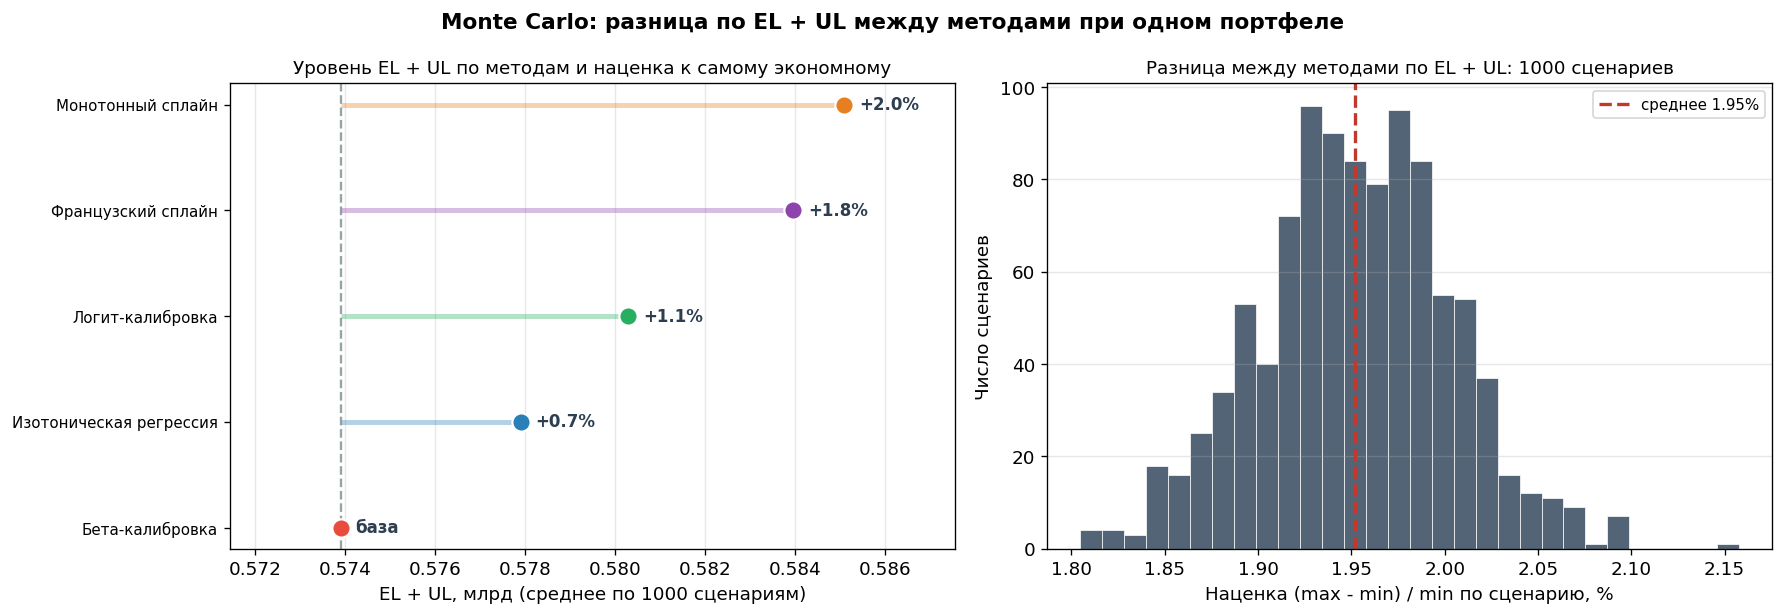

In [9]:
methods = list(summary["method"])
method_colors = {name: COLORS[i % len(COLORS)] for i, name in enumerate(methods)}

order = summary.sort_values("el_plus_ul_mean").reset_index(drop=True)
methods_sorted = order["method"].tolist()
levels_bln = order["el_plus_ul_mean"].to_numpy() / 1e9
cheapest = float(levels_bln.min())
markup = levels_bln / cheapest - 1.0

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# --- Панель А: уровень EL+UL по методам, наценка к самому экономному ---
ax = axes[0]
y = np.arange(len(methods_sorted))
ax.axvline(cheapest, color="#95a5a6", ls="--", lw=1.4, zorder=1)
for i, (name, lv, mk) in enumerate(zip(methods_sorted, levels_bln, markup)):
    ax.hlines(i, cheapest, lv, color=method_colors[name], lw=3, alpha=0.35, zorder=2)
    ax.scatter(lv, i, color=method_colors[name], s=120, zorder=5, edgecolor="white", linewidth=1.3)
    label = "база" if mk <= 1e-9 else f"+{mk:.1%}"
    ax.annotate(label, (lv, i), xytext=(9, 0), textcoords="offset points",
                va="center", ha="left", fontsize=10, fontweight="bold", color="#2c3e50")
ax.set_yticks(y)
ax.set_yticklabels(methods_sorted, fontsize=9)
ax.set_xlabel("EL + UL, млрд (среднее по 1000 сценариям)")
ax.set_title("Уровень EL + UL по методам и наценка к самому экономному", fontsize=11)
ax.margins(x=0.22)
ax.grid(axis="x", alpha=0.3)

# --- Панель Б: распределение межметодной наценки по 1000 сценариям ---
ax = axes[1]
rel = spread["rel_diff"].to_numpy() * 100.0
ax.hist(rel, bins=30, color="#34495e", alpha=0.85, edgecolor="white", linewidth=0.5)
mean_rel = float(rel.mean())
ax.axvline(mean_rel, color="#c0392b", ls="--", lw=2.0, label=f"среднее {mean_rel:.2f}%")
ax.set_xlabel("Наценка (max - min) / min по сценарию, %")
ax.set_ylabel("Число сценариев")
ax.set_title(f"Разница между методами по EL + UL: {len(rel)} сценариев", fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Monte Carlo: разница по EL + UL между методами при одном портфеле", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Интерпретация

- **Денежные метрики устойчивы к составу портфеля.** Полный размах max−min по 1000 сценариям: 2.2% от среднего у UL-капитала и RWA, 2.9% у EL + UL, 6.5% у среднего PD и EL. Выводы раздела 8 основного ноутбука не зависят от того, какие именно ~80% портфеля попали в выборку.

- **Межметодный разброс EL + UL внутри сценария невелик** (разделы 3a, 4): самый консервативный и самый экономный метод различаются в среднем на 1.95% (диапазон 1.80–2.16%). Порядок методов стабилен: бета-калибровка дешевле всех, монотонный сплайн дороже всех — в 1000 сценариях из 1000. Выбор калибратора не переворачивает капитальную картину.

- **Как целые модели все пять откалиброваны правильно.** Whole-model тест само-калибровки проходит на **100% сценариев IN-TIME у всех пяти методов** (раздел 3b) и на **100% из 12 независимых портфелей** (раздел 3c). Это ожидаемо: модели приведены к ЦТ и корректно оценивают суммарный уровень риска.

- **Просадка на OOT в разделе 3b (≈50%) — свойство базового портфеля, а не калибровки.** Monte Carlo ресемплит один портфель (`random_state=42`), в котором OOT-год вытянул неудачную реализацию: фактическая дефолтность 3.26% против собственного истинного PD 3.51%, то есть на 7% ниже. Все 1000 сценариев наследуют этот разрыв, поэтому доля прохождения садится к 50%. Раздел 3c показывает это прямо: на 12 независимых портфелях **предсказанный PD относится к ИСТИННОМУ как 1.011 (t = +1.05 против 1.0)** — систематического смещения калибровки нет, — тогда как фактическая дефолтность относится к истинному PD как 0.966. Бином-тест видит произведение этих двух эффектов (1.049) и на 2 сидах из 12 отвергает калибровку, которая в среднем несмещена. Доля прохождения на OOT — 83% (10/12), что при 12 наблюдениях статистически совместимо с ожидаемыми 95%.

- **Оговорка, которую стоит сказать вслух.** Несмещённость `pred_over_true` — это свойство **среднего** по портфелям, а не гарантия на каждом. По сидам она гуляет с sd ≈ 3.6% (от 0.966 до 1.093), потому что калибратор настраивается на фактические дефолты in-time периода, а не на их истинный PD, и наследует шум этой выборки. Поэтому отвергают тест те сиды, где оба шума сложились в одну сторону: seed 404 — калибровка +9% и дефолты −6%; seed 42 — +5% и −7%. Обратное тоже верно: seed 606 имеет худший в выборке `obs_over_true` (0.886) и всё равно проходит, потому что калибровка на нём точна. Ни один отдельный p-value — ни хороший, ни плохой — не говорит о калибровке столько, сколько раскладка на эти два множителя.

- **По-грейдовый тест против фиксированной мастер-шкалы — вторичная диагностика** (раздел 3b), и он строже whole-model по построению. Даже с поправкой Холма на множественность доля прохождения IN-TIME расходится широко: французский сплайн 79.5%, бета 66.5%, изотоника 51.7%, логит 46.2%, **монотонный сплайн 2.5%**. Причина этой строгости — не разладка калибровки: грейд задаётся **предсказанным** PD, поэтому в один бакет попадают заёмщики разного истинного риска, и их фактическая дефолтность тянется к среднему портфеля, а не к representative PD бакета (regression to the mean). Монотонный сплайн проваливает его чаще всех, оставаясь при этом на 100% корректным как целая модель, — это и есть иллюстрация того, что тест меряет форму разбиения, а не уровень риска. Выводы делаются по whole-model.

- **Портфель согласован с мастер-шкалой по построению.** Средний истинный PD каждого рейтинга равен representative PD, заявленному в его границах (см. `_draw_pd_inside_rating`), а у грейда E это ровно фигура мастер-шкалы ментора — 0.40. E занимает 5% портфеля, но даёт ~58% его суммарного PD, поэтому именно его согласование критично. Раньше генератор игнорировал заявленный representative PD, E реализовывал ~0.56, и портфель дефолтил на 4.6% вместо арифметических 3.45%, которые следуют из `mix × representative`.

- **Про OOT-сдвиг.** `oot_pd_lift` и `pandemic_pd_lift` сдвигают логит интенсивности риска, а не логит PD, поэтому их эффект на реализованный PD мал: заявленные 0.08 дают около +1.6%. Средний истинный PD по годам почти плоский (2020: 3.58%, 2023: 3.36%, 2024: 3.51%). **Это не стресс-сценарий**, и OOT-тест здесь проверяет переносимость калибровки на невиданную выборку, а не устойчивость к шоку.

**Про производительность.** Бустинг-скоринг, по-строчный IRB-капитал и грейды мастер-шкалы предвычислены один раз в `prepare_fixed_pipeline`; сценарий только индексирует свою случайную ~80%-подвыборку и суммирует. 1000 ранов считаются за минуты. Раздел 3c дороже — он честно переобучает пайплайн на каждом из 12 портфелей.
